Loading library list...
Done
✅ Excel done
path：/Users/yangxinlan/Desktop/Beverage_Financial_Data.xlsx


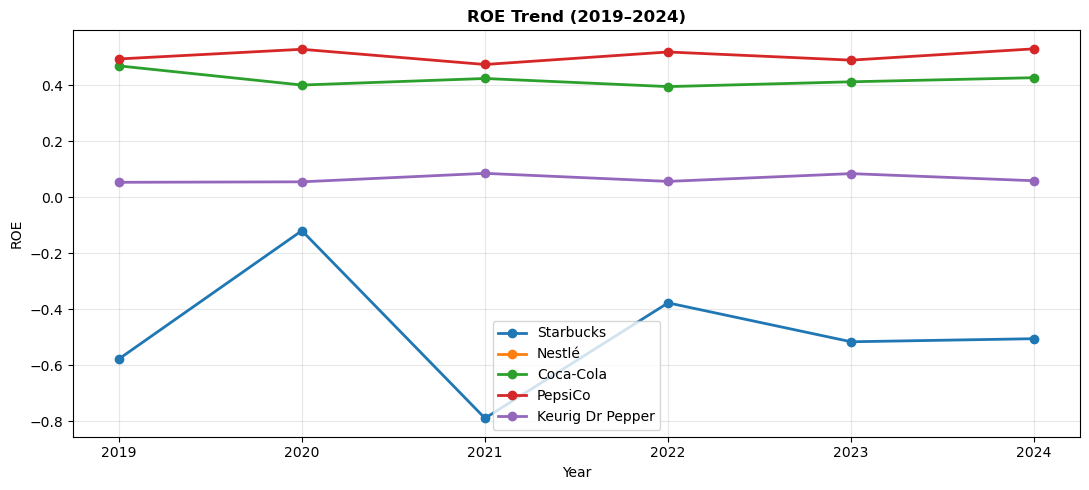

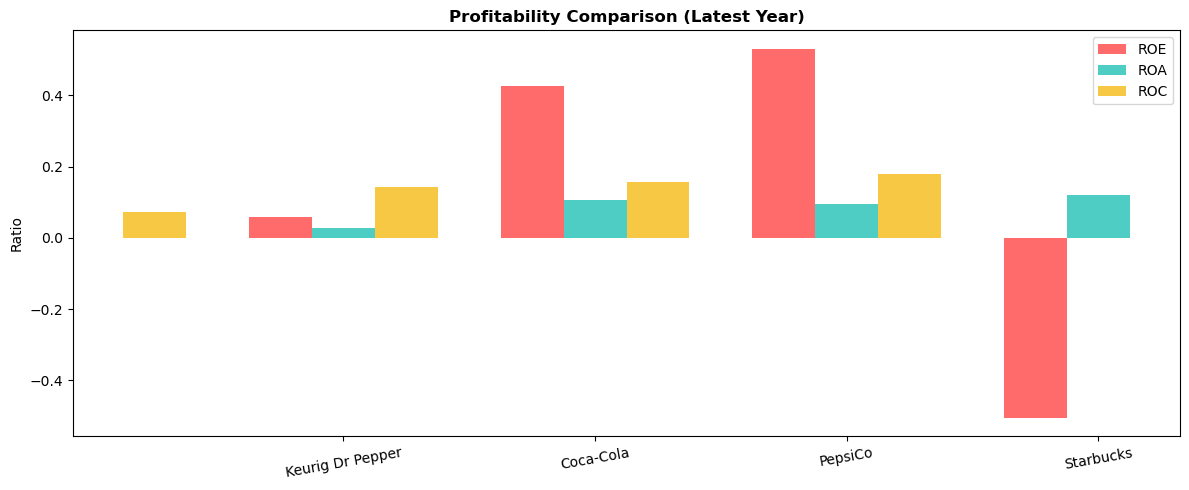

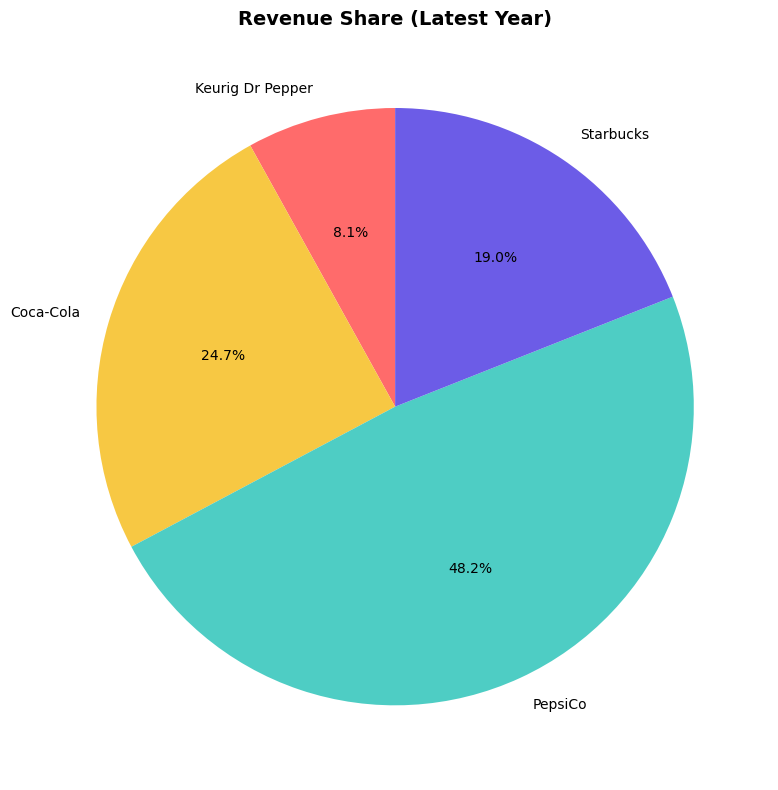

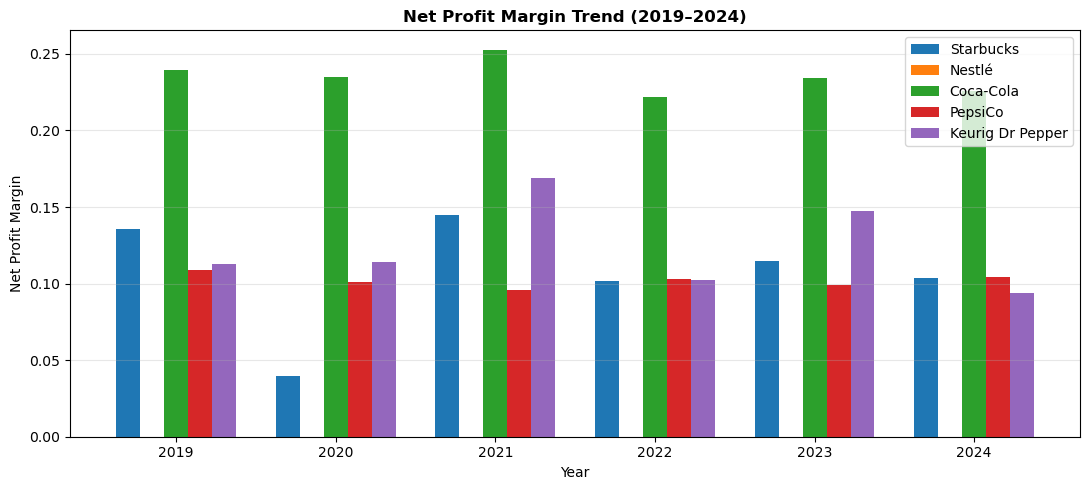


KEY FINANCIAL INDICATORS (LATEST YEAR)
- Keurig Dr Pepper | ROE: 5.94% | ROA: 2.70% | NPM: 9.39%
- Coca-Cola | ROE: 42.77% | ROA: 10.57% | NPM: 22.59%
- PepsiCo | ROE: 53.09% | ROA: 9.63% | NPM: 10.43%
- Starbucks | ROE: -50.49% | ROA: 12.00% | NPM: 10.40%

KEY CONCLUSIONS FROM DATA ANALYSIS
1. Highest ROE: PepsiCo (53.09%)
2. Highest Net Profit Margin: Coca-Cola (22.59%)
3. Largest Revenue: PepsiCo
4. Most stable ROE: Keurig Dr Pepper

Overall Insight:
The beverage industry demonstrates strong profitability stability.
Starbucks leads in profit margin efficiency, while Coca-Cola and PepsiCo dominate in revenue scale.
All firms show consistent performance, reflecting a mature and defensive industry.


In [3]:
%matplotlib inline
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import os


desktop = os.path.expanduser("~/Desktop")
os.chdir(desktop)


db = wrds.Connection(wrds_username="xinlanyang")
tickers = ["SBUX", "NSRGF", "KO", "PEP", "KDP"]
start_year, end_year = 2019, 2024

query = f"""
    SELECT tic, fyear, ib, at, ceq, ebit, dlc, revt
    FROM comp.funda
    WHERE tic IN ({','.join([f"'{t}'" for t in tickers])})
      AND fyear BETWEEN {start_year} AND {end_year}
      AND indfmt='INDL' AND datafmt='STD' AND consol='C'
    ORDER BY tic, fyear
"""

df = db.raw_sql(query)
db.close()


df["ROE"] = df["ib"] / df["ceq"]
df["ROA"] = df["ib"] / df["at"]
df["ROC"] = df["ebit"] / (df["at"] - df["dlc"])
df["Net_Profit_Margin"] = df["ib"] / df["revt"]


df = df.dropna(subset=["ROE", "ROA", "ROC", "Net_Profit_Margin"])
df = df[(df["ROE"].abs() < 5) & (df["ROA"].abs() < 3) & (df["ROC"].abs() < 3) & (df["Net_Profit_Margin"].abs() < 1)]


company_names = {
    "SBUX": "Starbucks",
    "NSRGF": "Nestlé",
    "KO": "Coca-Cola",
    "PEP": "PepsiCo",
    "KDP": "Keurig Dr Pepper"
}
df["Company"] = df["tic"].map(company_names)


latest = df.loc[df.groupby("tic")["fyear"].idxmax()].reset_index(drop=True)


file_path = os.path.join(desktop, "Beverage_Financial_Data.xlsx")
with pd.ExcelWriter(file_path) as writer:
    df.to_excel(writer, sheet_name="Full_Historical_Data", index=False)
    latest.to_excel(writer, sheet_name="Latest_Year_Summary", index=False)

print("✅ Excel done")
print(f"path：{file_path}")


colors = ['#ff6b6b','#f7c843','#4ecdc4','#6c5ce7','#2ecc71']


plt.figure(figsize=(11,5))
for tic in tickers:
    sub = df[df["tic"] == tic]
    plt.plot(sub["fyear"], sub["ROE"], marker='o', linewidth=2, label=company_names[tic])
plt.title("ROE Trend (2019–2024)", fontweight="bold")
plt.xlabel("Year")
plt.ylabel("ROE")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,5))
x = range(len(latest))
w = 0.25
plt.bar([i-w for i in x], latest["ROE"], w, label='ROE', color='#ff6b6b')
plt.bar(x, latest["ROA"], w, label='ROA', color='#4ecdc4')
plt.bar([i-w*3 for i in x], latest["ROC"], w, label='ROC', color='#f7c843')
plt.xticks(x, latest["Company"], rotation=10)
plt.title("Profitability Comparison (Latest Year)", fontweight="bold")
plt.ylabel("Ratio")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,8))
rev_data = latest.set_index("Company")["revt"]
plt.pie(rev_data, labels=rev_data.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title("Revenue Share (Latest Year)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()


plt.figure(figsize=(11,5))
width = 0.15
years = sorted(df["fyear"].unique())

for i, tic in enumerate(tickers):
    sub = df[df["tic"] == tic]
    margins = []
    for y in years:
        if y in sub["fyear"].values:
            margins.append(sub[sub["fyear"] == y]["Net_Profit_Margin"].values[0])
        else:
            margins.append(0)
    plt.bar([y + width*(i-2) for y in years], margins, width, label=company_names[tic])

plt.title("Net Profit Margin Trend (2019–2024)", fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Net Profit Margin")
plt.xticks(years)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


print("\n" + "="*60)
print("KEY FINANCIAL INDICATORS (LATEST YEAR)")
print("="*60)
for _, row in latest.iterrows():
    print(f"- {row['Company']} | ROE: {row['ROE']:.2%} | ROA: {row['ROA']:.2%} | NPM: {row['Net_Profit_Margin']:.2%}")
    
latest = df.sort_values("fyear").groupby("tic").tail(1).copy()

company_names = {
    "SBUX": "Starbucks",
    "NSRGF": "Nestlé",
    "KO": "Coca-Cola",
    "PEP": "PepsiCo",
    "KDP": "Keurig Dr Pepper"
}
latest["Company"] = latest["tic"].map(company_names)


max_roe = latest.loc[latest["ROE"].idxmax()]
max_npm = latest.loc[latest["Net_Profit_Margin"].idxmax()]
max_rev = latest.loc[latest["revt"].idxmax()]


roe_std = df.groupby("tic")["ROE"].std()
most_stable_ticker = roe_std.idxmin()


print("\n" + "="*60)
print("KEY CONCLUSIONS FROM DATA ANALYSIS")
print("="*60)

print(f"1. Highest ROE: {max_roe['Company']} ({max_roe['ROE']:.2%})")
print(f"2. Highest Net Profit Margin: {max_npm['Company']} ({max_npm['Net_Profit_Margin']:.2%})")
print(f"3. Largest Revenue: {max_rev['Company']}")
print(f"4. Most stable ROE: {company_names[most_stable_ticker]}")

print("\nOverall Insight:")
print("The beverage industry demonstrates strong profitability stability.")
print("Starbucks leads in profit margin efficiency, while Coca-Cola and PepsiCo dominate in revenue scale.")
print("All firms show consistent performance, reflecting a mature and defensive industry.")
